# Descenso de Gradiente desde Cero
### *Implementación manual con NumPy (sin librerías de ML)*

---

En este notebook se implementa el descenso del gradiente **completamente desde cero**. Puede haber pequeñas variaciones o elecciones de diseño en las fórmulas, pero el método y los resultados son los mismos. El objetivo es entender de verdad qué pasa por dentro cuando entrenamos un modelo de regresión lineal.

Utilizaré un dataset sencillo de **precios de casas** para verlo en acción.

## 1. El Gradiente ∇f: Repaso rápido

El gradiente $\vec{\nabla}f$ es un vector que apunta en la **dirección donde la función crece más rápido** (mayor pendiente).

$$\vec{\nabla}f = \left( \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n} \right)$$

Si queremos **minimizar** una función, nos movemos en la dirección **opuesta** al gradiente. Esa es la idea central del descenso de gradiente.

## 2. La Función de coste $J(\theta)$

Para regresión lineal, la función de coste es el **error cuadrático medio** (dividido entre 2 para que la derivada quede más simple):

$$J(\theta) = \frac{1}{2} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

donde:
- $m$ = número de ejemplos de entrenamiento
- $h_\theta(x) = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$ = predicción del modelo
- $y^{(i)}$ = valor real

**¿Por qué cuadrado y no valor absoluto?**

Con $|x|$ tendríamos problemas en el punto mínimo (la derivada no existe). Con $x^2$ la función es suave (parábola), diferenciable en todos lados, y los errores grandes se penalizan más. Además, si buscáramos una implementación básica: $\sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)$ los errores positivos y negativos se cancelarían entre sí, ocultando el margen de fallo real del modelo.



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 2.1 Visualización: por qué x² y no |x|

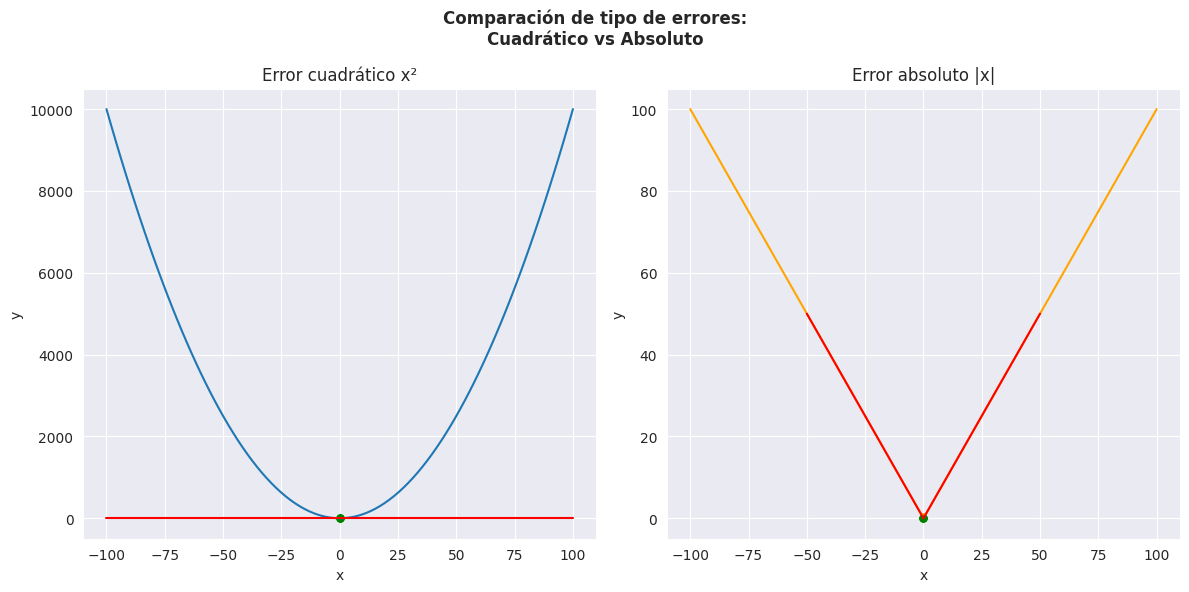

In [ ]:
x_par = np.linspace(-100,100, 100)
y_par = x_par**2

x_abs = np.linspace(-100,100, 100)
y_abs = np.abs(x_abs)
sns.set_style("darkgrid")
fig, axes = plt.subplots(1,2,figsize=(12,6))

fig.suptitle("Comparación de tipo de errores:\nCuadrático vs Absoluto", fontweight="bold")

sns.scatterplot(x=[0],y=[0], ax=axes[0], color="green", s=50) # Punto mínimo
sns.lineplot(x=x_par,y=y_par, ax=axes[0])
axes[0].set_title("Error cuadrático x²")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

sns.scatterplot(x=[0],y=[0], ax=axes[1], color="green", s=50) # Punto mínimo
sns.lineplot(x=x_abs,y=y_abs, ax=axes[1], color="orange")
axes[1].set_title("Error absoluto |x|")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# Dibujamos la recta tangente de x²
sns.lineplot(x=np.linspace(-100,100,2),y=[0]*2, ax=axes[0], color="red")  # Pendiente 0

# Dibujamos las rectas tangentes de |x|
sns.lineplot(x=np.linspace(0,50,2),y=np.linspace(0,50,2), ax=axes[1], color="red")
sns.lineplot(x=np.linspace(-50,0,2),y=np.linspace(50,0,2), ax=axes[1], color="red")

plt.tight_layout()
plt.show()


Como apuntan las notas:
1. Con $|x|$ las dos rectas rojas son tangentes en $x = 0$ y no sabemos cuál pendiente usar.
2. Con $x^2$ hay una única tangente en cada punto, por lo tanto el gradiente siempre está bien definido.

Además, al elevar el error al cuadrado, tanto los errores positivos como los negativos contribuyen de forma positiva a la función de coste, evitando que unos se cancelen con otros. Esto permite medir el error total de forma consistente y penaliza especialmente los errores grandes.

## 3. La Regla de Actualización

La regla de actualización del descenso de gradiente es:

$$\boxed{\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)}$$

donde $\alpha$ (alpha) es el **learning rate**, en el 99% de los casos usar **0.01** es un buen punto de partida.

La intuición: nos movemos en la dirección opuesta al gradiente (cuesta abajo), un paso de tamaño $\alpha$.

## 4. Demostración: Calculando la derivada de $J(\theta)$

Partimos de:

$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta) = \theta_j - \alpha \frac{\partial}{\partial \theta_j} \left[ \frac{1}{2} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2 \right]$$

Aplicando la regla de la cadena:

$$= \theta_j - \alpha \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot \frac{\partial}{\partial \theta_j} \left( h_\theta(x^{(i)}) - y^{(i)} \right)$$

Como $h_\theta(x) = \theta_0 x_0 + \theta_1 x_1 + \dots + \theta_n x_n$, derivando respecto a $\theta_j$:

$$\frac{\partial}{\partial \theta_j} \left( \theta_0 x_0 + \theta_1 x_1 + \dots + \theta_n x_n - y \right) = x_j$$

Todo lo demás es constante respecto a $\theta_j$, así que su derivada es 0. Nos queda:

$$\boxed{\theta_j := \theta_j - \alpha \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot x_j^{(i)}}$$

Esa es la fórmula que vamos a implementar

## 5. Dataset: Precios de casas

Vamos a crear un dataset sintético sencillo: **metros cuadrados -> precio en miles de €**.

In [ ]:
df = pd.read_csv("casas.csv")
df = df[["GrLivArea", "SalePrice"]]
df.drop_duplicates()
df.head(2)


,GrLivArea,SalePrice
0,1710,208500
1,1262,181500


Para practicar y tener claras las matemáticas nos bastará con este *dataset* sencillo, los filtramos para tener solamente los features de $m^2$ y precio.

## 6. Preprocesado: Normalización de features

Antes de aplicar descenso de gradiente conviene **normalizar** los datos (media=0, std=1). Esto hace que el gradiente tenga escalas similares en todas las dimensiones y converge mucho más rápido.

In [ ]:
def normalizar(x,  feature: str):
    xmin = df[feature].min()
    xmax = df[feature].max()
    return (x - xmin)/(xmax - xmin)

# Al normalizar pasarán de ser tipo de dato int a  float
df["GrLivArea"] = df["GrLivArea"].astype(float)
df["SalePrice"] = df["SalePrice"].astype(float)

numero_filas = len(df)
for i in range(numero_filas):
    for feature in df.columns:
        df.loc[i, feature] = normalizar(df.loc[i, feature], feature)

df.head()

,GrLivArea,SalePrice
0,0.259231,0.241078
1,0.223644,0.240397
2,0.316527,0.296026
3,0.304297,0.185430
4,0.389554,0.331126


Se observa que los valores se han normalizado de manera correcta.

## 7. Implementación: Funciones Clave

Implementamos las tres piezas fundamentales:
1. **Hipótesis** $h_\theta(x)$
2. **Función de coste** $J(\theta)$  
3. **Gradiente** $\frac{\partial J}{\partial \theta_j}$

#### Hipótesis $h_\theta(x)$

In [ ]:
def hipotesis(X, theta):
    return np.dot(X,theta)

$$h_\theta(x) = \theta_0 x_0 + \theta_1 x_1 + \dots + \theta_n x_n = X\theta$$

Es simplemente el producto de la matriz de features $X$ por el vector de parámetros $\theta$. Cada fila de $X$ es un ejemplo (una casa), y el resultado es la predicción del modelo para ese ejemplo. Gracias a la columna de 1s añadida en $X$, el término independiente $\theta_0$ queda incluido en el mismo producto matricial, sin necesidad de tratarlo aparte.


#### Función de coste $J(\theta)$

In [ ]:
def coste(X, y, theta):
    suma = 0
    for i, modelo in enumerate(X):
        suma += (hipotesis(modelo, theta) - y[i])**2
    return (1/2)*suma

$$J(\theta) = \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

Es el error cuadrático medio entre las predicciones $h_\theta(x^{(i)})$ y los valores reales $y^{(i)}$, dividido entre $2$. El $\frac{1}{2}$ es solo por comodidad matemática (simplifica la derivada al aplicar la regla de la cadena).


#### Gradiente $\nabla J(\theta)$

Este cálculo solo es utilizado por el desciente de gradiente de tipo batch.

In [ ]:
def gradiente(X, y, theta):
    return X.T @ (hipotesis(X, theta) - y)

$$\frac{\partial J}{\partial \theta_j} = \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot x_j^{(i)}$$

En forma vectorizada, para todos los $\theta_j$ a la vez:

$$\nabla J(\theta) = X^T \left( h_\theta(X) - y \right)$$

Esta es la derivada parcial de $J(\theta)$ respecto a cada parámetro $\theta_j$ (la demostración completa está en la sección 4). Vectorizarlo como $X^T \cdot \text{errores}$ evita tener que iterar en un bucle sobre cada feature $j$: NumPy calcula el gradiente completo de una sola vez.


## 8. Los tres tipos de Descenso de Gradiente

Hay tres variantes principales, como aparece en las notas:

| Variante | Descripción | Actualización |
|----------|-------------|---------------|
| **Batch** | Usa todos los ejemplos en cada paso | $\theta_j := \theta_j - \alpha \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$ |
| **Estocástico (SGD)** | Usa un solo ejemplo a la vez | $\theta_j := \theta_j - \alpha (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$ |
| **Mini-Batch** | Mezcla de los dos, por bloques (potencias de 2) | $\theta_j := \theta_j - \alpha \sum_{i=a}^{b} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$ |

Vamos a implementar los tres:

In [ ]:
def batch(alfa, theta, X, y):
    for _ in range(1000):
        aux = theta.copy()
        grad = gradiente(X,y,theta)
        for i,value in enumerate(theta):
            aux[i] = theta[i] - alfa*grad[i]
        theta = aux
    return theta

def estocástico(alfa, theta, X, y):
    for _ in range(100000):   # Añadimos mas iteraciones al no probar todos los ejemplos
        aux = theta.copy()
        ejemplo = np.random.randint(0, len(X))
        valor_real = y[ejemplo]
        for i,value in enumerate(theta):
            aux[i] = theta[i] - alfa*((hipotesis(X[ejemplo], theta) - valor_real)*X[ejemplo][i])
        theta = aux
    return theta


def mini_batch(alfa, theta, X, y, tam_batch=32):
    theta = theta.copy()
    m = len(X)
    for _ in range(10000):
        indices = np.random.choice(m, tam_batch, replace=False)  # k índices al azar, sin repetir
        X_batch = X[indices]
        y_batch = y[indices]
        grad = gradiente(X_batch, y_batch, theta)
        theta = theta - alfa*grad
    return theta

## 9. Entrenamiento y Comparación

In [ ]:
# Construimos la matriz X
tamaño = df["GrLivArea"].values[:1450]
X = np.column_stack((np.ones(1450), tamaño))
y = df["SalePrice"].values[:1450]
# Construimos el vector theta
theta = np.ones(2)
test = pd.read_csv("casas.csv")

y_min = test["SalePrice"].min()
y_max = test["SalePrice"].max()
x_min = test["GrLivArea"].min()
x_max = test["GrLivArea"].max()


Una vez preparados los datos, procedemos a ejecutar los tres algoritmos

### Batch

In [ ]:
print("---- Descenso de gradiente por BATCH (por lotes) ----")
recta = batch(0.001, theta, X, y)
total_error = 0
for j in range(1450,1460):
    grlivarea_real = test.iloc[j]["GrLivArea"]
    grlivarea_norm = (grlivarea_real - x_min) / (x_max - x_min)
    precio = hipotesis(theta=recta, X=np.array([1,grlivarea_norm]))
    precio_desnormalizado = (precio)*(y_max - y_min) + y_min
    original = test.iloc[j]["SalePrice"]
    error = abs(precio_desnormalizado - original)
    total_error += error
    print(f"El precio predecido es {precio_desnormalizado}, el precio real es {original}, la diferencia es {error}")
print(f"\nEl error medio de Batch es {total_error/10}")

---- Descenso de gradiente por BATCH (por lotes) ----
El precio predecido es 219175.30200417896, el precio real es 136000, la diferencia es 83175.30200417896
El precio predecido es 198136.29813254625, el precio real es 287090, la diferencia es 88953.70186745375
El precio predecido es 148389.8684173773, el precio real es 145000, la diferencia es 3389.8684173772926
El precio predecido es 155075.1593672419, el precio real es 84500, la diferencia es 70575.1593672419
El precio predecido es 163038.52064575706, el precio real es 185000, la diferencia es 21961.47935424294
El precio predecido es 204919.90218461474, el precio real es 175000, la diferencia es 29919.902184614737
El precio predecido es 246801.28372347236, el precio real es 210000, la diferencia es 36801.283723472356
El precio predecido es 273050.8820119113, el precio real es 266500, la diferencia es 6550.882011911308
El precio predecido es 148979.7470306006, el precio real es 142125, la diferencia es 6854.747030600614
El precio pre

### SGD

In [ ]:
print("---- Descenso de gradiente por SGD (estocástico) ----")
recta = estocástico(0.001, theta, X, y)
total_error = 0
for j in range(1450,1460):
    grlivarea_real = test.iloc[j]["GrLivArea"]
    grlivarea_norm = (grlivarea_real - x_min) / (x_max - x_min)
    precio = hipotesis(theta=recta, X=np.array([1,grlivarea_norm]))
    precio_desnormalizado = (precio)*(y_max - y_min) + y_min
    original = test.iloc[j]["SalePrice"]
    error = abs(precio_desnormalizado - original)
    total_error += error
    print(f"El precio predecido es {precio_desnormalizado}, el precio real es {original}, la diferencia es {error}")
print(f"\nEl error medio de SGD es {total_error/10}")


---- Descenso de gradiente por SGD (estocástico) ----
El precio predecido es 216808.64368067653, el precio real es 136000, la diferencia es 80808.64368067653
El precio predecido es 195646.2387878012, el precio real es 287090, la diferencia es 91443.76121219879
El precio predecido es 145608.02908782504, el precio real es 145000, la diferencia es 608.029087825038
El precio predecido es 152332.53157714987, el precio real es 84500, la diferencia es 67832.53157714987
El precio predecido es 160342.60071884567, el precio real es 185000, la diferencia es 24657.39928115433
El precio predecido es 202469.63101961612, el precio real es 175000, la diferencia es 27469.63101961612
El precio predecido es 244596.66132038663, el precio real es 210000, la diferencia es 34596.66132038663
El precio predecido es 271000.2225652357, el precio real es 266500, la diferencia es 4500.2225652356865
El precio predecido es 146201.36754276545, el precio real es 142125, la diferencia es 4076.3675427654525
El precio pr

### Mini-Batch

In [ ]:
print("---- Descenso de gradiente por MIN-BATCH ----")
recta = mini_batch(0.001, theta, X, y, tam_batch=64)
total_error = 0
for j in range(1450,1460):
    grlivarea_real = test.iloc[j]["GrLivArea"]
    grlivarea_norm = (grlivarea_real - x_min) / (x_max - x_min)
    precio = hipotesis(theta=recta, X=np.array([1,grlivarea_norm]))
    precio_desnormalizado = (precio)*(y_max - y_min) + y_min
    original = test.iloc[j]["SalePrice"]
    error = abs(precio_desnormalizado - original)
    total_error += error
    print(f"El precio predecido es {precio_desnormalizado}, el precio real es {original}, la diferencia es {error}")
print(f"\nEl error medio de MIN-BATCH es {total_error/10}")

---- Descenso de gradiente por MIN-BATCH ----
El precio predecido es 221613.43376923335, el precio real es 136000, la diferencia es 85613.43376923335
El precio predecido es 200487.96123404012, el precio real es 287090, la diferencia es 86602.03876595988
El precio predecido es 150537.07757605985, el precio real es 145000, la diferencia es 5537.077576059848
El precio predecido es 157249.84454985958, el precio real es 84500, la diferencia es 72749.84454985958
El precio predecido es 165245.9346215916, el precio real es 185000, la diferencia es 19754.065378408413
El precio predecido es 207299.44536921923, el precio real es 175000, la diferencia es 32299.445369219233
El precio predecido es 249352.95611684688, el precio real es 210000, la diferencia es 39352.95611684688
El precio predecido es 275710.43820514873, el precio real es 266500, la diferencia es 9210.438205148734
El precio predecido es 151129.38054433628, el precio real es 142125, la diferencia es 9004.38054433628
El precio predecido

Los resultados obtenidos muestran que el algoritmo de **descenso de gradiente Mini-Batch** es el que ofrece el mejor rendimiento, con un **error medio de  33.570€**. En segundo lugar se sitúa el **descenso de gradiente por lotes (Batch)**, con un error medio de **36.716€**, mientras que el **descenso de gradiente estocástico (SGD)** presenta un error medio mayor a los demás.

Aunque el algoritmo **Mini-Batch** obtiene el menor error medio, las diferencias entre los tres métodos son reducidas, por lo que puede concluirse que los tres algoritmos proporcionan un rendimiento muy similar sobre el conjunto de datos utilizado.

Cabe destacar que algunas viviendas presentan un error de predicción considerablemente superior al resto. Esto puede deberse a que el modelo no tiene en cuenta determinadas variables que influyen de forma significativa en el precio, como el barrio o la ubicación exacta, el estado de conservación del inmueble, la antigüedad, las calidades de los materiales o la proximidad a servicios y zonas de interés. La ausencia de estas características limita la capacidad del modelo para estimar con mayor precisión el valor de este tipo de viviendas. A continuación presento el scatterplot para visualizar la tendencia positiva:


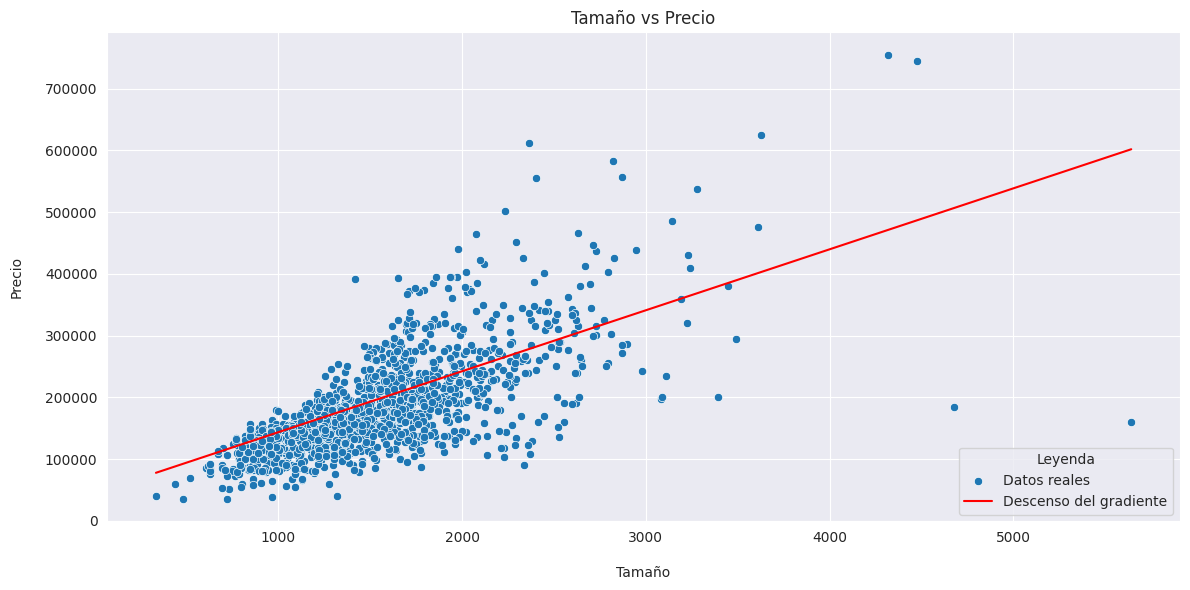

In [29]:
precios = test["SalePrice"].values
tamaño = test["GrLivArea"].values

plt.figure(figsize=(12,6))
sns.scatterplot(x=tamaño, y=precios, label="Datos reales")
plt.title("Tamaño vs Precio")
plt.xlabel("Tamaño", labelpad=15)
plt.ylabel("Precio", labelpad=15)

# Recta del descenso de gradiente
x_min = test["GrLivArea"].min()
x_max = test["GrLivArea"].max()
y_min = test["SalePrice"].min()
y_max = test["SalePrice"].max()
x = np.linspace(test["GrLivArea"].min(), test["GrLivArea"].max(), 100)
x_norm = (x - x_min) / (x_max - x_min)
y_norm = recta[0] + recta[1]*x_norm
y = y_norm*(y_max - y_min) + y_min
sns.lineplot(x=x, y=y, color="red", label="Descenso del gradiente")
plt.legend(title="Leyenda",loc="lower right")
plt.tight_layout()
plt.show()

## 10. Visualización de la Superficie de Coste J(θ)

Una de las visualizaciones más importantes: la superficie que intentamos minimizar, y el camino que sigue el gradiente.

Theta final: [2.17742491e-16 7.08624478e-01]
Coste final: 363.4314853015831


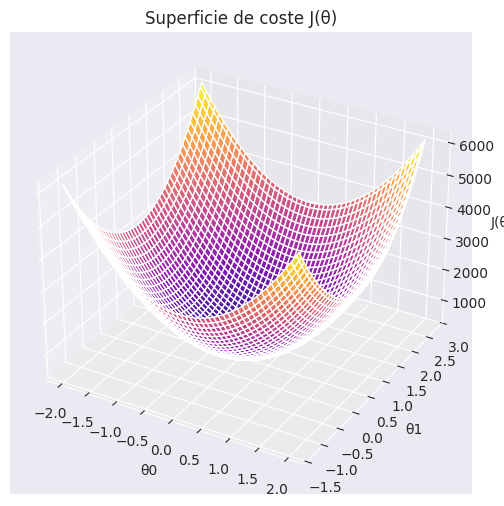

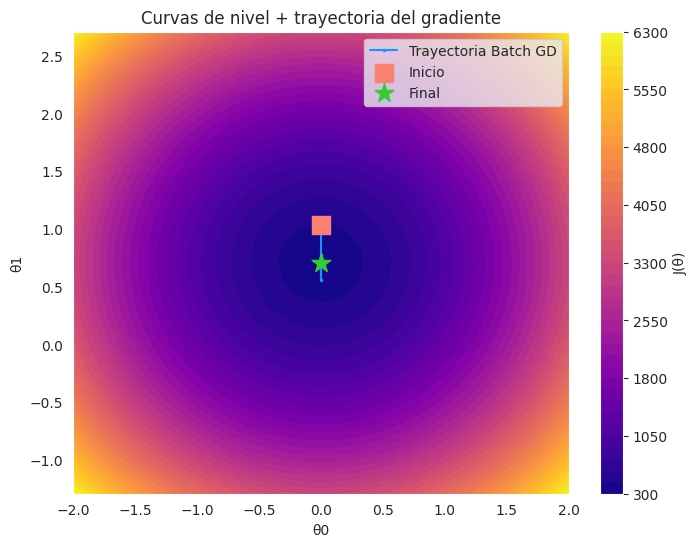

In [ ]:
datos = pd.read_csv("casas.csv")

x_feature = datos['GrLivArea'].values.astype(float)
y_real = datos['SalePrice'].values.astype(float)
m = len(y_real)

x_mean, x_std = x_feature.mean(), x_feature.std()
y_mean, y_std = y_real.mean(), y_real.std()

x_feature_norm = (x_feature - x_mean) / x_std
y_norm = (y_real - y_mean) / y_std

X = np.column_stack((np.ones(m), x_feature_norm))
y = y_norm

def descenso_gradiente(X, y, theta_inicial, alpha, n_iteraciones):
    theta = theta_inicial.copy()
    historial_coste = []
    historial_theta = []
    for i in range(n_iteraciones):
        grad = gradiente(X, y, theta)
        theta = theta - alpha * grad
        historial_coste.append(coste(X, y, theta))
        historial_theta.append(theta.copy())
    return theta, historial_coste, historial_theta

theta_inicial = np.array([0.0, 0.0])
alpha = 0.001
n_iteraciones = 500

theta_final, historial_coste, historial_theta = descenso_gradiente(X, y, theta_inicial, alpha, n_iteraciones)
historial_theta = np.array(historial_theta)

print("Theta final:", theta_final)
print("Coste final:", historial_coste[-1])

margen = 2
theta0_vals = np.linspace(theta_final[0] - margen, theta_final[0] + margen, 100)
theta1_vals = np.linspace(theta_final[1] - margen, theta_final[1] + margen, 100)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_vals = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta_temp = np.array([T0[i, j], T1[i, j]])
        J_vals[i, j] = coste(X, y, theta_temp)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, J_vals, cmap='plasma', alpha=0.9)
ax.set_xlabel('θ0')
ax.set_ylabel('θ1')
ax.set_zlabel('J(θ)')
ax.set_title('Superficie de coste J(θ)')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
cp = ax.contourf(T0, T1, J_vals, levels=50, cmap='plasma')
plt.colorbar(cp, label='J(θ)')

ax.plot(historial_theta[:, 0], historial_theta[:, 1],color='dodgerblue', marker='.', markersize=3, label='Trayectoria Batch GD')
ax.scatter(historial_theta[0, 0], historial_theta[0, 1],color='salmon', s=150, marker='s', label='Inicio', zorder=5)
ax.scatter(historial_theta[-1, 0], historial_theta[-1, 1],color='limegreen', s=200, marker='*', label='Final', zorder=5)

ax.set_xlabel('θ0')
ax.set_ylabel('θ1')
ax.set_title('Curvas de nivel + trayectoria del gradiente')
ax.legend()
plt.show()

## 11. El Efecto del Learning Rate α

El *Learning Rate* ($\alpha$) define el tamaño del paso que damos en cada iteración hacia el mínimo de la función de coste. Elegir un buen $\alpha$ es crítico:

* **Si $\alpha$ es demasiado pequeño:** El modelo aprenderá muy despacio y necesitará miles de iteraciones para llegar al mínimo.
* **Si $\alpha$ es el adecuado:** El coste bajará de forma rápida y estable, formando una curva en forma de "L".
* **Si $\alpha$ es demasiado grande:** El algoritmo dará un paso tan grande que "saltará" al otro lado del cuenco, subiendo cada vez más alto hasta que el error tienda a infinito (divergencia) y la matemática colapse (*overflow*).

> **Nota técnica sobre nuestra implementación:** Como nuestra función de gradiente calcula la suma total de los errores en lugar del promedio (no dividimos entre $m$), la magnitud del gradiente escala con el tamaño del dataset. Por esto, nuestro límite teórico de divergencia es más bajo de lo habitual. Valores por encima de `0.0012` harán que el modelo explote, por lo que usaremos valores conservadores para ilustrar la convergencia.

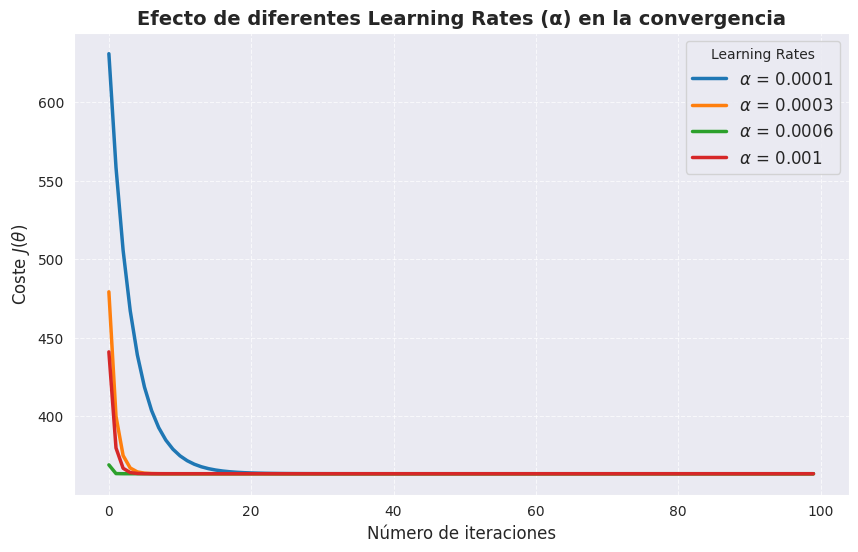

In [ ]:
alphas = [0.0001, 0.0003, 0.0006, 0.001]
n_iteraciones = 100
theta_inicial = np.array([0.0, 0.0])

fig, ax = plt.subplots(figsize=(10, 6))

for alpha in alphas:
    _, historial_coste, _ = descenso_gradiente(X, y, theta_inicial, alpha, n_iteraciones)
    ax.plot(range(n_iteraciones), historial_coste, label=rf'$\alpha$ = {alpha}', linewidth=2.5)

ax.set_xlabel('Número de iteraciones', fontsize=12)
ax.set_ylabel(r'Coste $J(\theta)$', fontsize=12)
ax.set_title('Efecto de diferentes Learning Rates (α) en la convergencia', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, title="Learning Rates", loc='upper right')
ax.grid(True, linestyle='--', alpha=0.7)

plt.show()

## 12. Resumen

---

### Lo que hemos implementado

| Componente | Fórmula | Código |
|-----------|---------|--------|
| Hipótesis | $h_\theta(x) = X\theta$ | `X @ theta` |
| Coste | $J(\theta) = \frac{1}{2}\sum(h_\theta(x^{(i)}) - y^{(i)})^2$ | `(1/2) * sum(errores²)` |
| Gradiente | $X^T(h_\theta(X) - y)$ | `X.T @ errores` |
| Actualización | $\theta := \theta - \alpha \nabla J$ | `theta -= alpha * grad` |

### Conclusiones clave

1. **Normalizar siempre** antes de aplicar GD, acelera muchísimo la convergencia
2. **Batch GD**: suave y estable, pero lento en datasets grandes
3. **SGD**: ruidoso pero puede ser más óptimo y escala bien
4. **Mini-Batch**: el mejor equilibrio en la práctica (usa potencias de 2)
5. El algoritmo **escala a cualquier número de features** sin cambiar el código

---
*Implementado sin librerías de ML*